In [1]:
import torch
import trimesh
import numpy as np
import glob
import json
import os
import fast_simplification
import matplotlib.pyplot as plt
import PIL

In [5]:
hand_mesh_path = "data/V2D_ego_reconstruction_10_videos/10/hand_mesh/hand_mesh_moge_aligned_perhand_smooth.npz"
object_poses_folder = "data/V2D_ego_reconstruction_10_videos/10/outputs/poses_moge"
object_mesh_path = "data/V2D_ego_reconstruction_10_videos/10/outputs/mesh_scaled.obj"

In [6]:
object_poses_paths = glob.glob(os.path.join(object_poses_folder, "*.json"))
object_poses_paths = sorted(object_poses_paths, key=lambda x: int(os.path.basename(x).split('.')[0]))
object_poses = []
for i in object_poses_paths:
    with open(i, "r") as f:
        data = json.load(f)
    rotation = data['rotation'] 
    translation = data['translation']

    w, x, y, z = data['rotation'] 
    sx, sy, sz = data['scale']
    tx, ty, tz = data['translation']
    R = np.array([
        [1 - 2*y*y - 2*z*z,  2*x*y - 2*w*z,      2*x*z + 2*w*y],
        [2*x*y + 2*w*z,      1 - 2*x*x - 2*z*z,  2*y*z - 2*w*x],
        [2*x*z - 2*w*y,      2*y*z + 2*w*x,      1 - 2*x*x - 2*y*y],
    ], dtype=np.float64)
    M = np.eye(4, dtype=np.float64)
    M[:3, :3] = R @ np.diag([sx, sy, sz])
    M[:3, 3] = [tx, ty, tz]
    object_poses.append(M)

obj_poses = np.stack(object_poses).astype(np.float32)
obj_mesh = trimesh.load(object_mesh_path)
obj_mesh = obj_mesh.simplify_quadric_decimation(face_count=10000)
obj_verts = np.concatenate([obj_mesh.vertices, np.ones((obj_mesh.vertices.shape[0], 1))], axis=1).astype(np.float32)
obj_verts = (obj_poses[:, None, :, :] @ obj_verts[None, :, :, None])[:, :, :3, 0]
obj_faces = obj_mesh.faces
obj_normals = obj_mesh.vertex_normals
obj_normals = (obj_poses[:, None, :3, :3] @ obj_normals[:, :, None])[:, :, :, 0]


# obj_verts = obj_verts @ object_poses[0].T
hand_mesh_data = np.load(hand_mesh_path)
l_hand_verts = hand_mesh_data['verts'][0]
l_hand_faces = hand_mesh_data['faces_left']
r_hand_verts = hand_mesh_data['verts'][1]
r_hand_faces = hand_mesh_data['faces_right']

l_hand_verts_normals = []
for t in range(l_hand_verts.shape[0]):
    mesh = trimesh.Trimesh(
        vertices=l_hand_verts[t],
        faces=l_hand_faces
    )
    l_hand_verts_normals.append(mesh.vertex_normals)
l_hand_verts_normals = np.stack(l_hand_verts_normals)

r_hand_verts_normals = []
for t in range(r_hand_verts.shape[0]):
    mesh = trimesh.Trimesh(
        vertices=r_hand_verts[t],
        faces=r_hand_faces
    )
    r_hand_verts_normals.append(mesh.vertex_normals)
r_hand_verts_normals = np.stack(r_hand_verts_normals)

In [7]:


def smooth_verts(verts, kernel_size=13, std=2.0):
    gauss_kernel = torch.exp(-torch.linspace(-1. * kernel_size, 1. * kernel_size, kernel_size)**2 / (2 * std**2))
    gauss_kernel = gauss_kernel / gauss_kernel.sum()
    gauss_kernel = gauss_kernel[None, None, :].repeat(3, 1, 1)
    verts_in = torch.from_numpy(verts)  
    verts_in = verts_in.permute(1, 2, 0)
    verts_out = torch.conv1d(verts_in, gauss_kernel, padding=kernel_size//2, groups=3)
    verts_out = verts_out.permute(2, 0, 1)
    return verts_out.numpy()


def compute_vel(verts, dt=1.0/30.0):
    verts_t = torch.from_numpy(verts)
    verts_prev = verts_t.roll(shifts=(1,), dims=(0,))
    verts_prev[0] = verts_t[0]
    verts_vel = verts_t - verts_prev
    return verts_vel.numpy() / dt


def to_vel_visual(verts, vel):
    vec = np.column_stack((verts, verts + (vel * 0.1)))
    vec = vec.reshape((-1, 2, 3))
    path = trimesh.load_path(vec)
    return path


def to_normals_visual(verts, normals):
    vec = np.column_stack((verts, verts + (normals * 0.01)))
    path = trimesh.load_path(vec.reshape((-1, 2, 3)))
    return path


In [8]:
obj_verts_smooth = smooth_verts(obj_verts, kernel_size=25, std=3.0)
l_hand_verts_smooth = smooth_verts(l_hand_verts, kernel_size=25, std=3.0)
r_hand_verts_smooth = smooth_verts(r_hand_verts, kernel_size=25, std=3.0)

obj_verts_vel = compute_vel(obj_verts_smooth)
l_hand_verts_vel = compute_vel(l_hand_verts_smooth)
r_hand_verts_vel = compute_vel(r_hand_verts_smooth)



In [35]:
def p_pos(a_pos, b_pos, sigma=0.1):
    # gaussian distribution
    return np.exp(-((a_pos - b_pos)**2).sum(axis=-1) / sigma**2)

def p_vel(a_vel, b_vel, sigma=0.1):
    # gaussian distribution
    return np.exp(-((a_vel - b_vel)**2).sum(axis=-1) / sigma**2)

def p_normal(a_normal, b_normal, sigma=0.25):
    # von mises fisher distribution
    return np.exp(-((a_normal + b_normal)**2).sum(axis=-1) / sigma**2)
    
    


In [44]:
l_hand_verts.shape

(780, 778, 3)

In [40]:
import tqdm
t = 240
l_touch = []
r_touch = []
for t in tqdm.tqdm(range(0, obj_verts.shape[0], 1)):
    obj_verts_t = obj_verts[t]
    obj_verts_vel_t = obj_verts_vel[t]
    obj_verts_normals_t = obj_normals[t]

    l_hand_verts_t = l_hand_verts[t]
    l_hand_verts_vel_t = l_hand_verts_vel[t]
    l_hand_verts_normals_t = l_hand_verts_normals[t]

    r_hand_verts_t = r_hand_verts[t]
    r_hand_verts_vel_t = r_hand_verts_vel[t]
    r_hand_verts_normals_t = r_hand_verts_normals[t]

    p_pos_rt =  p_pos(r_hand_verts_t[:, None, :], obj_verts_t[None, :, :])
    p_vel_rt = p_vel(r_hand_verts_vel_t[:, None, :], obj_verts_vel_t[None, :, :])
    p_normal_rt = p_normal(r_hand_verts_normals_t[:, None, :], obj_verts_normals_t[None, :, :])

    p_combined_rt = p_pos_rt * p_normal_rt

    p_pos_lt =  p_pos(l_hand_verts_t[:, None, :], obj_verts_t[None, :, :])
    p_vel_lt = p_vel(l_hand_verts_vel_t[:, None, :], obj_verts_vel_t[None, :, :])
    p_normal_lt = p_normal(l_hand_verts_normals_t[:, None, :], obj_verts_normals_t[None, :, :])

    p_combined_lt = p_pos_lt * p_normal_lt

    l_touch.append(float(p_combined_rt.max()))
    r_touch.append(float(p_combined_lt.max()))

 58%|█████▊    | 451/780 [03:31<02:34,  2.13it/s]


KeyboardInterrupt: 

In [12]:
from scipy.optimize import linear_sum_assignment

idx_r_hand, idx_obj = linear_sum_assignment(-p_combined_rt)
p_match_r = p_combined_rt[idx_r_hand, idx_obj]
p_match_r_path_vec = np.permute_dims(np.array([r_hand_verts_t[idx_r_hand], obj_verts_t[idx_obj]]), (1, 0, 2))
p_match_r_path_vec = p_match_r_path_vec[p_match_r > 0.5]


idx_l_hand, idx_obj = linear_sum_assignment(-p_combined_lt)
p_match_l = p_combined_lt[idx_l_hand, idx_obj]
p_match_l_path_vec = np.permute_dims(np.array([l_hand_verts_t[idx_l_hand], obj_verts_t[idx_obj]]), (1, 0, 2))
p_match_l_path_vec = p_match_l_path_vec[p_match_l > 0.5]


In [13]:

obj_mesh = trimesh.Trimesh(
    vertices=obj_verts[t],
    faces=obj_faces
)
# obj_mesh.visual.vertex_colors = np.ones((obj_verts.shape[1], 3)) * 0.5
# obj_mesh.visual.vertex_colors = o_colors_t
left_hand_mesh = trimesh.Trimesh(
    vertices=l_hand_verts[t],
    faces=l_hand_faces,
)
left_hand_mesh.visual.vertex_colors = np.ones((l_hand_verts.shape[1], 3)) * 0.5
# left_hand_mesh.visual.vertex_colors = l_colors
right_hand_mesh = trimesh.Trimesh(
    vertices=r_hand_verts[t],
    faces=r_hand_faces
)
right_hand_mesh.visual.vertex_colors = np.ones((r_hand_verts.shape[1], 3)) * 0.5



obj_vel_visual = to_vel_visual(obj_verts[t], obj_verts_vel[t])
# l_hand_vel_visual = to_vel_visual(l_hand_verts[t], left_hand_verts_vel[t])
# r_hand_vel_visual = to_vel_visual(r_hand_verts[t], right_hand_verts_vel[t])

# obj_normals_visual = to_normals_visual(obj_verts[t], obj_normals[t])
# l_hand_normals_visual = to_normals_visual(l_hand_verts[t], l_hand_normals[t])
# r_hand_normals_visual = to_normals_visual(r_hand_verts[t], r_hand_normals[t])

obs = [
    obj_mesh, left_hand_mesh, right_hand_mesh
]
if p_match_r_path_vec.shape[0] > 0:
    p_match_r_path = trimesh.load_path(p_match_r_path_vec)
    p_match_r_path.colors = np.array([[0, 255, 0, 1]]).repeat(len(p_match_r_path.entities), axis=0)
    obs.append(p_match_r_path)
if p_match_l_path_vec.shape[0] > 0:
    p_match_l_path = trimesh.load_path(p_match_l_path_vec)
    p_match_l_path.colors = np.array([[0, 255, 0, 1]]).repeat(len(p_match_l_path.entities), axis=0)
    obs.append(p_match_l_path)
scene = trimesh.Scene(
    obs
)
scene.show(background=[0, 0, 0, 255])

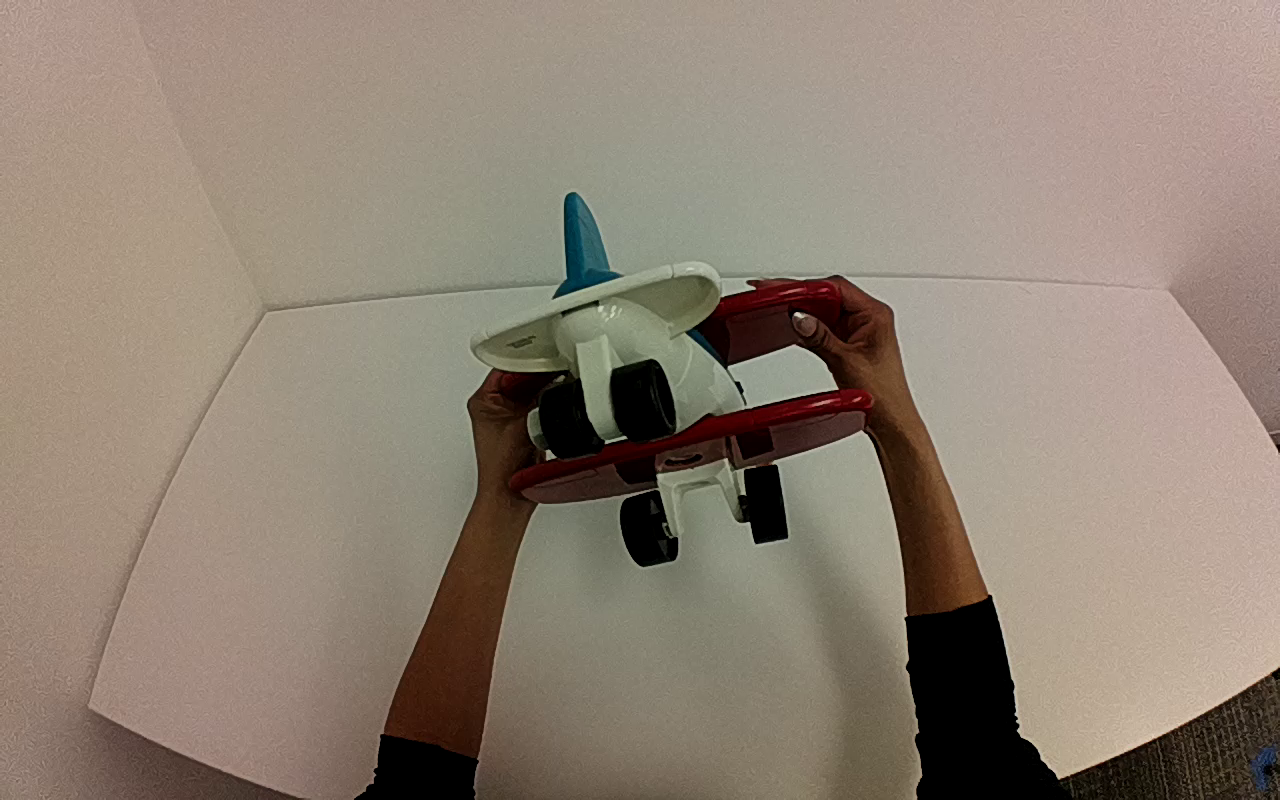

In [808]:
PIL.Image.open(f"data/V2D_ego_reconstruction_10_videos/10/outputs/frames/{t:06d}.png")